## Import & Configuration

- Set Number of Class = 20
- Cut Images that contains more than 50% unknown
- Set Number of workers
- Have Validation Loss
- Save ด้วย Validate Loss
- Map Wall To unknown
- เปลี่ยนโมเดล Decoder


m1 = 16/5e-5 Add BDD10K

m2 = 32/8e-5

m3 = 32/2e-4 Add Mapilary Vitas

m4 = 32/2e-4 Add Dropout

M5 = 32/2e-4 ลด Dropout 0.5->0.2, 0.25->0.1

M6 = 32/2e-4 ลด Dropout 0.5->0.1, 0.25->0.05

M7 = 32/1e-4 cut dataset เหลือแค่ mv bdd


In [1]:
import torch, gc
torch.cuda.set_device(3)
torch.cuda.empty_cache()
gc.collect()

import os

print("Full workesrs:", os.cpu_count())
mynum_workers = os.cpu_count() // 3
print(f"Using {mynum_workers} workers for DataLoader")

# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32             #   8
NUM_CLASSES = 20            #   151   
LR = 1e-4                   #   1e-5
EPOCHS = 60                 #   30
IMG_SIZE = (224, 224)
print(f"✅ Using device: {DEVICE}")
savemodel = "L14m7"

Full workesrs: 72
Using 24 workers for DataLoader
✅ Using device: cuda


In [2]:
# import torch

# # จำลอง mask ที่มีค่าเกินช่วง
# masks = torch.tensor([
#     [0, 1, 2, 255],
#     [3, 149, 150, 999]
# ])

# NUM_CLASSES = 150

# print("🎨 Original mask:")
# print(masks)

# # ---- ขั้นตอนที่ 1: แปลง 255 → 0 ----
# masks_step1 = torch.where(masks == 255, 0, masks)
# print("\n🧩 After where (255 → 0):")
# print(masks_step1)

# # ---- ขั้นตอนที่ 2: จำกัดค่าให้อยู่ใน [0, NUM_CLASSES - 1] ----
# masks_step2 = torch.clamp(masks_step1, 0, NUM_CLASSES - 1).long()
# print("\n✅ After clamp(0, NUM_CLASSES-1):")
# print(masks_step2)


In [3]:
# ============================================================
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import CLIPModel
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import re
import copy
import time

muse_dir = "/home/chenyinjia/data/dataset/muses"
ade20k_dir = "/home/chenyinjia/data/dataset/ADE20ID"
cs_dir = "/home/chenyinjia/data/dataset/cityscapes"
acdc_dir = "/home/chenyinjia/data/dataset/acdc"
bdd_dir = "/home/chenyinjia/data/dataset/bdd100k"
mv_dir = "/home/chenyinjia/data/dataset/mapillary_vistas"


clip32_dir = "/home/chenyinjia/clip-vit-large-patch14"


In [4]:
# ============================================================
# 🧠 Baseline CLIP + Segmentation Head (for MUSES Dataset)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import CLIPModel
from torchvision.utils import make_grid




## Dataset Definition

In [5]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image

# ============================================================
# 🔧 ADE20K official decoder
# ============================================================
def ade20k_rgb_to_class(mask_rgb: np.ndarray):
    """Decode ADE20K RGB mask to class IDs (official MIT method)."""
    mask_id = (
        mask_rgb[:, :, 0].astype(np.int32)
        + 256 * mask_rgb[:, :, 1].astype(np.int32)
        + 256 * 256 * mask_rgb[:, :, 2].astype(np.int32)
    )
    class_id = mask_id % 256
    return class_id.astype(np.int64)

# --- Cityscapes label set (index reference) ---
cityscapes_labels = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light", "traffic sign",
    "vegetation", "terrain", "sky", "person", "rider", "car", "truck", "bus", 
    "train", "motorcycle", "bicycle", "unknown"
]

# --- ADE20K → Cityscapes Unified Mapping ---
ADE20K_TO_CITYSCAPES = {
    0: 255,   # background → unknown
    1: 255,    # wall
    2: 2,    # building
    3: 10,   # sky
    4: 255,    # floor → unknown
    5: 8,    # tree → vegetation
    6: 255,   # ceiling → unknown
    7: 0,    # road
    8: 255,   # bed
    9: 255,   # windowpane
    10: 8,   # grass → vegetation
    11: 255,  # cabinet → unknown
    12: 1,   # sidewalk
    13: 11,  # person
    14: 9,   # earth → terrain
    15: 255,   # door → unknown
    16: 255,  # table
    17: 255,   # mountain → terrain
    18: 8,   # plant → vegetation
    19: 255,  # curtain
    20: 255,  # chair
    21: 13,  # car
    22: 255,   # water → terrain
    23: 255,  # painting
    24: 255,  # sofa
    25: 255,  # shelf
    26: 2,   # house → building
    27: 255,   # sea → terrain
    28: 255,  # mirror
    29: 255,   # rug → terrain
    30: 9,   # field → terrain
    31: 255,  # armchair
    32: 255,  # seat
    33: 4,   # fence
    34: 255,  # desk
    35: 255,   # rock → terrain
    36: 255,  # wardrobe
    37: 255,  # lamp
    38: 255,  # bathtub
    39: 4,   # railing → fence
    40: 255,  # pillow
    41: 255,  # base
    42: 255,  # box
    43: 5,   # column → pole
    44: 7,   # signboard → traffic sign
    45: 255,  # chest of drawers
    46: 255,  # counter
    47: 9,   # sand → terrain
    48: 255,  # sink
    49: 2,   # skyscraper → building
    50: 255,  # fireplace
    51: 255,  # refrigerator
    52: 255,  # grandstand
    53: 0,   # path → road
    54: 255,  # stairs
    55: 0,   # runway → road
    56: 255,  # case
    57: 255,  # pool table
    58: 255,  # pillow
    59: 255,   # screen door → terrain
    60: 255, # stairway
    61: 255,   # river → terrain
    62: 9,   # bridge → building
    63: 255,  # bookcase 
    64: 255,  # blind
    65: 255,  # coffee table
    66: 255,  # toilet
    67: 8,    # flower → vegetation
    68: 255,  # book
    69: 9,    # hill → terrain
    70: 255,  # bench
    71: 255,  # countertop
    72: 255,  # stove
    73: 8,    # palm → vegetation
    74: 255,  # kitchen island
    75: 255,  # computer
    76: 255,  # swivel chair
    77: 255,  # boat → bicycle (closest moving object type)
    78: 255,  # bar
    79: 255,  # arcade machine
    80: 2,   # hovel → building
    81: 15,  # bus
    82: 255,  # towel
    83: 255,  # light
    84: 14,  # truck
    85: 2,   # tower → building
    86: 255,  # chandelier
    87: 5,   # awning → pole
    88: 5,   # streetlight → pole
    89: 255,  # booth
    90: 255,  # television receiver
    91: 255,  # airplane → motorcycle (generic vehicle)
    92: 0,   # dirt track → road
    93: 255,  # apparel
    94: 5,   # pole
    95: 9,   # land → terrain
    96: 4,   # bannister → fence
    97: 255,  # escalator
    98: 255,  # ottoman
    99: 255,  # bottle
    100: 255, # buffet
    101: 255, # poster
    102: 255, # stage
    103: 15, # van → bus
    104: 255, # ship → bicycle (vehicle)
    105: 255,  # fountain → terrain
    106: 255, # conveyer belt
    107: 255, # canopy
    108: 255, # washer
    109: 255, # plaything
    110: 255,  # swimming pool → terrain
    111: 255, # stool
    112: 255, # barrel
    113: 255, # basket
    114: 255,  # waterfall → terrain
    115: 255, # tent
    116: 255, # bag
    117: 17, # minibike → motorcycle
    118: 255, # cradle
    119: 255, # oven
    120: 255, # ball
    121: 255, # food
    122: 255, # step
    123: 255, # tank (ambiguous)
    124: 255, # trade name
    125: 255, # microwave
    126: 255, # pot
    127: 11, # animal → person (animate)
    128: 18, # bicycle
    129: 255,  # lake → terrain
    130: 255, # dishwasher
    131: 255, # screen
    132: 255, # blanket
    133: 255, # sculpture
    134: 255, # hood
    135: 5,  # sconce → pole
    136: 255, # vase
    137: 6,  # traffic light
    138: 255, # tray
    139: 255, # ashcan
    140: 255, # fan
    141: 9,  # pier → terrain
    142: 255, # crt screen
    143: 255, # plate
    144: 255, # monitor
    145: 255, # bulletin board
    146: 255, # shower
    147: 255, # radiator
    148: 255, # glass
    149: 255, # clock
    150: 255, # flag
}


def convert_ade20k_to_cityscapes(mask: np.ndarray):
    """Convert ADE20K mask IDs (0–149) → Unified Cityscapes space (0–19)."""
    out = np.zeros_like(mask, dtype=np.int64)
    for k, v in ADE20K_TO_CITYSCAPES.items():
        out[mask == k] = v
    # print("Unique ADE mask before map:", np.unique(mask))
    # print("Unique after map:", np.unique(out))

    return out

# ============================================================
# 🔹 ADE20K Dataset Loader
# ============================================================
class ADE20KDataset(Dataset):
    def __init__(self, root_dir, filter20 = False ,split="train"):
        self.samples = []
        split_dir = {"train": "training", "val": "validation", "test": "validation"}[split]

        self.img_root = os.path.join(root_dir, "images", split_dir)
        self.mask_root = os.path.join(root_dir, "annotations", split_dir)

        if not os.path.exists(self.img_root):
            raise FileNotFoundError(f"❌ Missing folder: {self.img_root}")

        img_files = sorted([f for f in os.listdir(self.img_root) if f.endswith(".jpg")])
        mask_files = sorted([f for f in os.listdir(self.mask_root) if f.endswith(".png")])

        for img_file in img_files:
            base = img_file.replace(".jpg", "")
            seg_file = base + ".png"
            img_path = os.path.join(self.img_root, img_file)
            seg_path = os.path.join(self.mask_root, seg_file)

            # ---  20 Class filtering ---
            if filter20:
                mask_img = Image.open(seg_path)
                mask_rgb = np.array(mask_img.convert("RGB"), dtype=np.uint8)
                mask = ade20k_rgb_to_class(mask_rgb)
                mask = convert_ade20k_to_cityscapes(mask)

                unknown_ratio = np.mean(mask == 255)
                if unknown_ratio > 0.5:
                    continue
                
            if os.path.exists(seg_path):
                self.samples.append((img_path, seg_path))

        print(f"Loaded {len(self.samples)} ADE20K {split} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)

        # decode ADE20K mask
        mask_img = Image.open(mask_path)
        # if mask_img.mode == "I":
        #     mask = np.array(mask_img, dtype=np.int32) % 256
        # else:
        mask_rgb = np.array(mask_img.convert("RGB"), dtype=np.uint8)
        mask = ade20k_rgb_to_class(mask_rgb)

        mask = Image.fromarray(mask.astype(np.uint8)).resize(IMG_SIZE, resample=Image.NEAREST)
        mask = np.array(mask, dtype=np.uint8)
        mask = convert_ade20k_to_cityscapes(mask)

        image = np.array(image).transpose(2, 0, 1) / 255.0

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        return image, mask


# ============================================================
# 🔹 Unified MUSES Dataset Loader (All Weather + Day/Night)
# ============================================================
class MusesDataset(Dataset):
    def __init__(self, root_dir, weather="all",split="train"):
        self.root = root_dir
        self.split = split
        self.samples = []

        # sub-conditions ทั้งหมด เช่น clear/day, fog/night, rain/day ...
        all_weathers = ["clear", "fog", "rain", "snow"]
        if weather == "all":
            weathers = all_weathers
        elif isinstance(weather, (list, tuple)):
            weathers = [w for w in weather if w in all_weathers]
        elif weather in all_weathers:
            weathers = [weather]
        else:
            raise ValueError(f"Invalid weather '{weather}'. Choose from {all_weathers + ['all']}")
        # print(f"✅ Loading MUSES dataset with weathers: {weathers}")
        times_of_day = ["day", "night"]

        frame_root = os.path.join(root_dir, "frame_camera", split)
        mask_root = os.path.join(root_dir, "gt_semantic", split)

        for w in weathers:
            for tod in times_of_day:
                img_dir = os.path.join(frame_root, w, tod)
                mask_dir = os.path.join(mask_root, w, tod)

                if not (os.path.exists(img_dir) and os.path.exists(mask_dir)):
                    print(f"⚠️ Skip missing folder: {img_dir} or {mask_dir}")
                    continue

                img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
                mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith("_gt_labelTrainIds.png")])

                for img_file in img_files:
                    prefix = img_file.replace("_frame_camera.png", "")
                    match = [m for m in mask_files if prefix in m]
                    if match:
                        self.samples.append((os.path.join(img_dir, img_file),
                                             os.path.join(mask_dir, match[0])))

        print(f"Loaded {len(self.samples)} MUSES {split} samples with weathers: {weathers}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, resample=Image.NEAREST)

        image = np.array(image).transpose(2, 0, 1) / 255.0
        mask = np.array(mask, dtype=np.uint8)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)



# ============================================================
# 🔹 Cityscapes Dataset Loader (Final Verified)
# ============================================================
class CityscapesDataset(Dataset):
    def __init__(self, root_dir, split="train"):
        self.split = split
        self.samples = []

        self.img_root = os.path.join(root_dir, "leftImg8bit", split)
        self.mask_root = os.path.join(root_dir, "gtFine", split)

        if not os.path.exists(self.img_root):
            raise FileNotFoundError(f"❌ Missing folder: {self.img_root}")

        for city in os.listdir(self.img_root):
            img_dir = os.path.join(self.img_root, city)
            mask_dir = os.path.join(self.mask_root, city)
            if not os.path.exists(mask_dir):
                continue

            for f in os.listdir(img_dir):
                if f.endswith("_leftImg8bit.png"):
                    base = f.replace("_leftImg8bit.png", "")
                    # ✅ fallback: ถ้าไม่มี labelTrainIds ให้ใช้ labelIds
                    mask_file = None
                    for suffix in ["_gtFine_labelTrainIds.png"] : # , "_gtFine_labelIds.png"]
                        candidate = os.path.join(mask_dir, base + suffix)
                        if os.path.exists(candidate):
                            mask_file = candidate
                            break
                    if mask_file:
                        self.samples.append((os.path.join(img_dir, f), mask_file))

        print(f"Loaded {len(self.samples)} Cityscapes {split} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, 
                                                         resample=Image.NEAREST)
        image = np.array(image).transpose(2, 0, 1) / 255.0
        mask = np.array(mask, dtype=np.uint8)
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


# ============================================================
# 🔹 ACDC Dataset Loader (Multiple Weathers)
# ============================================================
class ACDCDataset(Dataset):
    """
    ACDC dataset loader supporting multiple weathers (fog/night/rain/snow)
    Structure expected:
        dataset/acdc/{rgb,gt}/{weather}/{split}/{video}/
    """
    def __init__(self, root_dir, weather="all", split="train"):
        self.split = split
        self.samples = []

        # --- weather selection ---
        all_weathers = ["fog", "night", "rain", "snow"]
        if weather == "all":
            weathers = all_weathers
        elif isinstance(weather, (list, tuple)):
            weathers = [w for w in weather if w in all_weathers]
        elif weather in all_weathers:
            weathers = [weather]
        else:
            raise ValueError(f"Invalid weather '{weather}'. Choose from {all_weathers + ['all']}")

        # --- collect all samples ---
        for w in weathers:
            rgb_root = os.path.join(root_dir, "rgb_anon", w, split)
            gt_root = os.path.join(root_dir, "gt", w, split)
            if not os.path.exists(rgb_root):
                print(f"⚠️ Skip weather '{w}' (not found: {rgb_root})")
                continue

            for vid in os.listdir(rgb_root):
                img_dir = os.path.join(rgb_root, vid)
                mask_dir = os.path.join(gt_root, vid)
                # if not os.path.isdir(img_dir):
                #     continue

                for f in os.listdir(img_dir):
                    if f.endswith("_rgb_anon.png"):
                        base = f.replace("_rgb_anon.png", "")
                        mask_file = None
                        for suffix in ["_gt_labelTrainIds.png"]: #  "_gt_labelTrainIds.png", "_gt_labelIds.png"
                            candidate = os.path.join(mask_dir, base + suffix)
                            if os.path.exists(candidate):
                                mask_file = candidate
                                break
                        if mask_file:
                            self.samples.append((os.path.join(img_dir, f), mask_file))
                            # print(f"✅ Found mask for image: {mask_file}")
                        else:
                            print(f"⚠️ Missing mask for image: {os.path.join(img_dir, f)}")
                            

        print(f"✅ Loaded {len(self.samples)} ACDC {split} samples from weathers: {weathers}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        # --- Load image + mask ---
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, 
                                                         resample=Image.NEAREST)

        image = np.array(image).transpose(2, 0, 1) / 255.0
        mask = np.array(mask, dtype=np.uint8)
        # # --- Optional transforms ---
        # if self.transform:
        #     image, mask = self.transform(image, mask)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

class BDD10kDataset(Dataset):
    def __init__(self, root_dir, split="train", onlyimg=False):
        self.split = split
        self.onlyimg = onlyimg
        self.samples = []

        self.img_root = os.path.join(root_dir, "images", "10k", split)
        self.mask_root = os.path.join(root_dir, "labels", split)

        if not os.path.exists(self.img_root):
            raise FileNotFoundError(f"❌ Missing folder: {self.img_root}")

        img_files = sorted([f for f in os.listdir(self.img_root) if f.endswith(".jpg")])
    
        for img_file in img_files:
            base = img_file.replace(".jpg", "")
            seg_file = base + "_train_id.png"
            img_path = os.path.join(self.img_root, img_file)
            seg_path = os.path.join(self.mask_root, seg_file)
                
            if os.path.exists(seg_path):
                self.samples.append((img_path, seg_path))

        print(f"Loaded {len(self.samples)} BDD10K {split} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, 
                                                         resample=Image.NEAREST)
        if self.onlyimg:
            return image, mask
        image = np.array(image).transpose(2, 0, 1) / 255.0
        mask = np.array(mask, dtype=np.uint8)
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [6]:
# # ===========================================================
# # MAPILLARY → CITYSCAPES MAPPING (ajustável)
# # ===========================================================
# mapillary_to_cityscapes = {
#     # Road
#     "Road": "road",
#     "Road Median": "road",
#     "Road Side": "road",
#     "Driveway": "road",
#     "Service Lane": "road",
#     "Lane Separator": "road",
#     "Parking": "unknown",  
#     "Parking Aisle": "road",
    
#     # Sidewalk
#     "Sidewalk": "sidewalk",
#     "Pedestrian Area": "sidewalk",
#     "Curb": "sidewalk",
#     "Curb Cut": "sidewalk",
    
#     # Building
#     "Building": "building",
#     "Garage": "building",
#     "Tunnel": "building",
#     "Bridge": "building",
    
#     # Wall / Fence
#     "Wall": "wall",
#     "Concrete Block": "wall",
#     "Barrier": "wall",
#     "Guard Rail": "wall",
#     "Fence": "fence",
#     "Ambiguous Barrier": "wall",
#     "Temporary Barrier": "wall",
    
#     # Pole
#     "Pole": "pole",
#     "Street Light": "pole",
#     "Utility Pole": "pole",
#     "Junction Box": "pole",
#     "CCTV Camera": "pole",
#     "Traffic Sign Frame": "pole",
#     "Manhole": "pole",
#     "Traffic Cone": "unknown",
#     "Fire Hydrant": "unknown",
#     "Bench": "unknown",
#     "Trash Can": "unknown",
#     "Mailbox": "unknown",
#     "Parking Meter": "unknown",
#     "Banner": "unknown",
#     "Car Mount": "unknown",
#     "Water Valve": "unknown",
    
#     # Traffic Light
#     "Traffic Light - General (Single)": "traffic light",
#     "Traffic Light - Pedestrians": "traffic light",
#     "Traffic Light - General (Upright)": "traffic light",
#     "Traffic Light - General (Horizontal)": "traffic light",
#     "Traffic Light - Cyclists": "traffic light",
#     "Traffic Light - Other": "traffic light",
    
#     # Traffic Sign
#     "Traffic Sign - Ambiguous": "traffic sign",
#     "Traffic Sign (Back)": "traffic sign",
#     "Traffic Sign - Direction (Back)": "traffic sign",
#     "Traffic Sign - Direction (Front)": "traffic sign",
#     "Traffic Sign (Front)": "traffic sign",
#     "Traffic Sign - Parking": "traffic sign",
#     "Traffic Sign - Temporary (Back)": "traffic sign",
#     "Traffic Sign - Temporary (Front)": "traffic sign",
    
#     # Vegetation / Terrain / Sky
#     "Vegetation": "vegetation",
#     "Tree": "vegetation",
#     "Grass": "vegetation",
#     "Bush": "vegetation",
#     "Terrain": "terrain",
#     "Sand": "terrain",
#     "Mountain": "terrain",
#     "Snow": "terrain",
#     "Ground": "terrain",
#     "Sky": "sky",
#     "Water": "unknown",  # sem equivalente direto
    
#     # Person / Rider
#     "Person": "person",
#     "Person Group": "person",
#     "Bicyclist": "rider",
#     "Motorcyclist": "rider",
#     "Other Rider": "rider",
    
#     # Vehicles
#     "Car": "car",
#     "Truck": "truck",
#     "Bus": "bus",
#     "Trailer": "truck",
#     "Caravan": "car",
#     "Motorcycle": "motorcycle",
#     "On Rails": "train",
#     "Other Vehicle": "car",  # genérico
#     "Vehicle Group": "car",  # genérico
#     "Wheeled Slow": "unknown",
#     "Boat": "unknown",
#     "Ego Vehicle": "unknown",
    
#     # Lane Markings (não usados no Cityscapes)
#     "Lane Marking - Dashed Line": "unknown",
#     "Lane Marking - Straight Line": "unknown",
#     "Lane Marking - Zigzag Line": "unknown",
#     "Lane Marking - Ambiguous": "unknown",
#     "Lane Marking - Arrow (Left)": "unknown",
#     "Lane Marking - Arrow (Other)": "unknown",
#     "Lane Marking - Arrow (Right)": "unknown",
#     "Lane Marking - Arrow (Split Left or Straight)": "unknown",
#     "Lane Marking - Arrow (Split Right or Straight)": "unknown",
#     "Lane Marking - Arrow (Straight)": "unknown",
#     "Lane Marking - Crosswalk": "unknown",
#     "Lane Marking - Give Way (Row)": "unknown",
#     "Lane Marking - Give Way (Single)": "unknown",
#     "Lane Marking - Hatched (Chevron)": "unknown",
#     "Lane Marking - Hatched (Diagonal)": "unknown",
#     "Lane Marking - Other": "unknown",
#     "Lane Marking - Stop Line": "unknown",
#     "Lane Marking - Symbol (Bicycle)": "unknown",
#     "Lane Marking - Symbol (Other)": "unknown",
#     "Lane Marking - Text": "unknown",
#     "Lane Marking (only) - Dashed Line": "unknown",
#     "Lane Marking (only) - Crosswalk": "unknown",
#     "Lane Marking (only) - Other": "unknown",
#     "Lane Marking (only) - Test": "unknown",
    
#     # Animais e outros
#     "Bird": "unknown",
#     "Ground Animal": "unknown",
# }


# mapillary_to_cityscapes = {k.lower(): v for k, v in mapillary_to_cityscapes.items()}
# label_to_id_cityscapes = {lbl: i for i, lbl in enumerate(cityscapes_labels)}

# # ===========================================================
# # FUNÇÃO: LER CORES DO MAPILLARY
# # ===========================================================
# def load_mapillary_color_to_label(config_path):
#     with open(config_path, "r") as f:
#         cfg = json.load(f)
#     color_to_label = {}
#     for obj in cfg["labels"]:
#         color = tuple(obj["color"])
#         label = obj["readable"].lower()
#         color_to_label[color] = label
#     return color_to_label

# import json
# config_path = "/home/chenyinjia/data/dataset/mapillary_vistas/config.json"
# color_to_label_mapillary = load_mapillary_color_to_label(config_path)

# # ===========================================================
# # CONVERSÃO: Máscara RGB → IDs Cityscapes
# # ===========================================================
# def convert_mapillary_mask_to_cityscapes_color(mask_rgb, color_to_label_mapillary, 
#                                                mapillary_to_cityscapes, 
#                                                label_to_id_cityscapes, void_id=255):
#     h, w, _ = mask_rgb.shape
#     city_mask = np.full((h, w), fill_value=void_id, dtype=np.uint8)

#     color_to_city_id = {}
#     for color, label in color_to_label_mapillary.items():
#         mapped = mapillary_to_cityscapes.get(label, None)
#         if mapped and mapped in label_to_id_cityscapes:
#             color_to_city_id[color] = label_to_id_cityscapes[mapped]

#     for color, city_id in color_to_city_id.items():
#         match = np.all(mask_rgb == color, axis=-1)
#         if city_id == 19:
#             city_mask[match] = 255
#         else:
#             city_mask[match] = city_id

#     return city_mask

# class BDD10kDataset(Dataset):
#     def __init__(self, root_dir, split="train", onlyimg=False):
#         self.split = split
#         self.onlyimg = onlyimg
#         self.samples = []

#         self.img_root = os.path.join(root_dir, "images", "10k", split)
#         self.mask_root = os.path.join(root_dir, "labels", split)

#         if not os.path.exists(self.img_root):
#             raise FileNotFoundError(f"❌ Missing folder: {self.img_root}")

#         img_files = sorted([f for f in os.listdir(self.img_root) if f.endswith(".jpg")])
    
#         for img_file in img_files:
#             base = img_file.replace(".jpg", "")
#             seg_file = base + "_train_id.png"
#             img_path = os.path.join(self.img_root, img_file)
#             seg_path = os.path.join(self.mask_root, seg_file)
                
#             if os.path.exists(seg_path):
#                 self.samples.append((img_path, seg_path))

#         print(f"Loaded {len(self.samples)} BDD10K {split} samples")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         img_path, mask_path = self.samples[idx]
#         image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
#         mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, 
#                                                          resample=Image.NEAREST)
#         if self.onlyimg:
#             return image, mask
#         image = np.array(image).transpose(2, 0, 1) / 255.0
#         mask = np.array(mask, dtype=np.uint8)
#         return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


### MV Dataset

In [7]:
class MVDataset(Dataset):
    def __init__(self, root_dir, split="train", onlyimg=False):
        self.split = split
        self.onlyimg = onlyimg
        self.samples = []

        self.img_root = os.path.join(root_dir, split, "images")
        self.mask_root = os.path.join(root_dir, split, "labels")

        if not os.path.exists(self.img_root):
            raise FileNotFoundError(f"❌ Missing folder: {self.img_root}")

        img_files = sorted([f for f in os.listdir(self.img_root) if f.endswith(".jpg")])
    
        for img_file in img_files:
            base = img_file.replace(".jpg", "")
            seg_file = base + ".png"
            img_path = os.path.join(self.img_root, img_file)
            seg_path = os.path.join(self.mask_root, seg_file)
                
            if os.path.exists(seg_path):
                #########################################################################
    
                #########################################################################
                self.samples.append((img_path, seg_path))

        print(f"Loaded {len(self.samples)} Mapillary Vistas {split} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        mask = Image.open(mask_path).convert("L").resize(IMG_SIZE, 
                                                         resample=Image.NEAREST)
        if self.onlyimg:
            return image, mask
        image = np.array(image).transpose(2, 0, 1) / 255.0
        mask = np.array(mask, dtype=np.uint8)
        
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [8]:
# k = np.array([[ 35,  48,  63],
#         [ 60,  77,  135],
#         [ 91, 112, 135]])
# flat=np.unique(k.flatten())
# print(flat)
# # np.unique(np.partition(mask.flatten(), -2)[-2])
# flat=np.partition(flat, -2)[-2]
# print(flat)

In [9]:
# len(cityscapes_labels)

In [10]:
# import numpy as np
# from PIL import Image
# import os

# root = "/home/chenyinjia/data/dataset/ADE20k"
# img_path = os.path.join(root, "images", "training", "ADE_train_00000001.jpg")
# mask_path = os.path.join(root, "annotations", "training", "ADE_train_00000001.png")

# mask = np.array(Image.open(mask_path))
# print("Mask shape:", mask.shape)
# print("Unique class IDs:", np.unique(mask)[:20])
# print("Max class ID:", mask.max())


In [11]:
# import numpy as np
# from PIL import Image
# import os
# from tqdm import tqdm

# mask_dir =  os.path.join(bdd_dir, "labels", "train")

# max_class = 0
# for f in tqdm(os.listdir(mask_dir)):
#     if not f.endswith(".png"): 
#         continue
#     mask = np.array(Image.open(os.path.join(mask_dir, f)))
#     max_class = max(max_class, mask.max())

# print(f"✅ Verified max class across ADE20K training: {max_class}")


## DataLoader Setup

In [12]:
from torch.utils.data import DataLoader, ConcatDataset

# ============================================================
# LOAD DATASETS ทั้งหมด (train / val / test)
# ============================================================
muses_train = MusesDataset(muse_dir, weather="all", split="train")
ade_train   = ADE20KDataset(ade20k_dir, split="train")
cs_train  = CityscapesDataset(cs_dir, split="train")
acdc_train  = ACDCDataset(acdc_dir, weather="all", split="train")
bdd_train = BDD10kDataset(bdd_dir, split="train")
mv_train = MVDataset(mv_dir, split="train")

print("\n")
muses_val = MusesDataset(muse_dir, weather="all", split="val")
ade_val   = ADE20KDataset(ade20k_dir, split="val")
cs_val  = CityscapesDataset(cs_dir, split="val")
acdc_val  = ACDCDataset(acdc_dir, weather="all", split="val")
bdd_val = BDD10kDataset(bdd_dir, split="val")
mv_val = MVDataset(mv_dir, split="val")

# # muses_test = MusesDataset(muse_dir, weather="all", split="test")
# ade_test   = ADE20KDataset(ade20k_dir, split="test")  # ✅ ADE ไม่มี test จริง → fallback ไป val
# cs_test  = CityscapesDataset(cs_dir, split="test")    # ✅ Cityscapes ไม่มี test จริง → fallback ไป val
# acdc_test  = ACDCDataset(acdc_dir, weather="all", split="test")  # ✅ ACDC ไม่มี test จริง → fallback ไป val

# ============================================================
# รวม dataset เข้าด้วยกัน
# ============================================================
# train_dataset = ConcatDataset([acdc_train, ade_train, 
#                                cs_train, muses_train, 
#                                bdd_train, mv_train])
# val_dataset   = ConcatDataset([acdc_val, ade_val, 
#                                cs_val, muses_val, 
#                                bdd_val, mv_val])
train_dataset = ConcatDataset([
                                bdd_train,  mv_train
                               ])
val_dataset   = ConcatDataset([
                                bdd_val, mv_val])
# test_dataset  = ConcatDataset([muses_test, ade_test, cs_test, acdc_test])  # ✅ ใช้ city_val แทน city_test เพราะไม่มี test set
print("All train Image:", len(train_dataset))

Loaded 1500 MUSES train samples with weathers: ['clear', 'fog', 'rain', 'snow']


Loaded 8437 ADE20K train samples
Loaded 2975 Cityscapes train samples
✅ Loaded 1600 ACDC train samples from weathers: ['fog', 'night', 'rain', 'snow']


Loaded 7000 BDD10K train samples


Loaded 18000 Mapillary Vistas train samples


Loaded 250 MUSES val samples with weathers: ['clear', 'fog', 'rain', 'snow']
Loaded 838 ADE20K val samples
Loaded 500 Cityscapes val samples
✅ Loaded 406 ACDC val samples from weathers: ['fog', 'night', 'rain', 'snow']
Loaded 1000 BDD10K val samples
Loaded 2000 Mapillary Vistas val samples
All train Image: 25000


In [13]:

# ====================================================
# 🔍 เช็คความสมดุลของ Dataset
# ====================================================
print("=" * 60)
print("📊 Dataset Size Check")
print("=" * 60)
print(f"ADE20K Train:     {len(ade_train):,} samples")
print(f"Cityscapes Train: {len(cs_train):,} samples")
print(f"MUSES Train:      {len(muses_train):,} samples")
print(f"ACDC Train:      {len(acdc_train):,} samples")
print(f"BDD10K Train:      {len(bdd_train):,} samples")
print(f"MV Train:      {len(mv_train):,} samples")
print(f"-" * 60)
print(f"Total Train:      {len(train_dataset):,} samples")
print(f"Total Val:        {len(val_dataset):,} samples")
print("=" * 60)

# คำนวณสัดส่วน
total = len(ade_train) + len(cs_train) + len(muses_train) + len(acdc_train) + len(bdd_train) + len(mv_train)

ade_ratio = len(ade_train) / total * 100
city_ratio = len(cs_train) / total * 100
muses_ratio = len(muses_train) / total * 100
acdc_ratio = len(acdc_train) / total *100
bdd_ratio = len(bdd_train) / total *100
mv_ratio = len(mv_train) / total *100

print(f"\n📈 Dataset Ratio:")
print(f"ADE20K:     {ade_ratio:.1f}%")
print(f"Cityscapes: {city_ratio:.1f}%")
print(f"MUSES:      {muses_ratio:.1f}%")
print(f"ACDC:      {acdc_ratio:.1f}%")
print(f"BDD10K:      {bdd_ratio:.1f}%")
print(f"MV:      {mv_ratio:.1f}%")
print("=" * 60)

# แนะนำ
if ade_ratio > 70:
    print("⚠️  ADE20K มีสัดส่วนมากกว่า 70%")
    print("💡 แนะนำ: ใช้ WeightedRandomSampler หรือ oversample dataset เล็ก")
else:
    print("✅ Dataset มีความสมดุลพอใช้ได้")

📊 Dataset Size Check
ADE20K Train:     8,437 samples
Cityscapes Train: 2,975 samples
MUSES Train:      1,500 samples
ACDC Train:      1,600 samples
BDD10K Train:      7,000 samples
MV Train:      18,000 samples
------------------------------------------------------------
Total Train:      25,000 samples
Total Val:        3,000 samples

📈 Dataset Ratio:
ADE20K:     21.4%
Cityscapes: 7.5%
MUSES:      3.8%
ACDC:      4.0%
BDD10K:      17.7%
MV:      45.6%
✅ Dataset มีความสมดุลพอใช้ได้


In [14]:
# ====================================================
# ⚖️ สร้าง WeightedRandomSampler เพื่อ Balance Dataset
# ====================================================
from torch.utils.data import WeightedRandomSampler

# กำหนด weights ให้แต่ละ dataset (ยิ่งน้อยยิ่ง weight สูง)
dataset_weights = {
    # 'ade': 2.13,      # ADE20K (มากสุด) → weight ต่ำ
    # 'acdc': 11.4,    # ACDC (น้อยสุด) → weight สูง
    # 'city': 6.1,     # Cityscapes (กลาง) → weight กลาง
    # 'muses': 12,    # MUSES (น้อยสุด) → weight สูง
    'bdd10k': 2.58,
    "mv": 1
}

# สร้าง weight สำหรับแต่ละ sample
sample_weights = []
# sample_weights.extend([dataset_weights['acdc']] * len(acdc_train))
# sample_weights.extend([dataset_weights['ade']] * len(ade_train))
# sample_weights.extend([dataset_weights['city']] * len(cs_train))
# sample_weights.extend([dataset_weights['muses']] * len(muses_train))
sample_weights.extend([dataset_weights['bdd10k']] * len(bdd_train))
sample_weights.extend([dataset_weights['mv']] * len(mv_train))

sample_weights = torch.DoubleTensor(sample_weights)

# สร้าง Sampler
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # สุ่มซ้ำได้
)

# ============================================================
# สร้าง DataLoader
# ============================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          sampler=weighted_sampler,  # ใช้ sampler แทน shuffle
                          num_workers=mynum_workers)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                          shuffle=False,
                          num_workers=mynum_workers)
# test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# แสดงสรุปผล
# ============================================================
print(f"\n✅✅ Train: {len(train_loader)} samples")
print(f"✅✅ Val:   {len(val_loader)} samples")
# print(f"✅✅ Test:  {len(test_dataset)} samples")



✅✅ Train: 782 samples
✅✅ Val:   94 samples


## check id distribution

In [15]:
import glob

def check_id_distribution(mask_dir, dataset_name, sample_size=100):
    """ตรวจสอบว่า IDs ที่มีจริงๆ มีอะไรบ้าง"""
    all_ids = set()
    mask_paths = sorted([f for f in os.listdir(mask_dir) if f.endswith(".jpg") or f.endswith(".png")])
    mask_paths = mask_paths[:sample_size]  # จำกัด sample_size ตัวอย่าง
    
    for path in mask_paths:
        path = os.path.join(mask_dir, path)
        if "TrainIds" in path or dataset_name == "MV" or dataset_name == "ADE20K" or "train_id" in path:
            mask = np.array(Image.open(path))
            unique_ids = np.unique(mask)
            all_ids.update(unique_ids.tolist())
    
    all_ids = sorted(all_ids)
    print(f"\n{dataset_name}:")
    print(f"  Total unique IDs: {len(all_ids)}")
    print(f"  ID range: {min(all_ids)} - {max(all_ids)}")
    print(f"  First 20 IDs: {all_ids[:20]}")
    print(f"  Last 20 IDs: {all_ids[-20:]}")
    
    return all_ids

mask_path = [
    '/home/chenyinjia/data/dataset/cityscapes/gtFine/train/aachen',
    '/home/chenyinjia/data/dataset/ADE20ID/annotations/training',
    '/home/chenyinjia/data/dataset/muses/gt_semantic/train/clear/day',
    '/home/chenyinjia/data/dataset/acdc/gt/rain/train/GOPR0400',
    "/home/chenyinjia/data/dataset/bdd100k/labels/train",
    "/home/chenyinjia/data/dataset/mapillary_vistas/train/labels"

]
# city_ids = check_id_distribution(mask_path[0], "Cityscapes")
# muses_ids = check_id_distribution(mask_path[2], "MUSES")
# ade_ids = check_id_distribution(mask_path[1], "ADE20K")
# acdc_ids = check_id_distribution(mask_path[3], 'ACDC')
acdc_ids = check_id_distribution(mask_path[4], 'BDD10K')
acdc_ids = check_id_distribution(mask_path[5], 'MV')


BDD10K:
  Total unique IDs: 19
  ID range: 0 - 255
  First 20 IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 255]
  Last 20 IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 255]



MV:
  Total unique IDs: 18
  ID range: 0 - 255
  First 20 IDs: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 255]
  Last 20 IDs: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 255]


In [16]:
# x = [True, True, False, True, True]
# np.all(np.array(x) == True)

## Data Sanity Check (การตรวจสอบความถูกต้องของข้อมูลภาพกับ mask)

ให้สังเกตว่า:

- ถ้า mask กลับด้าน → ต้องแก้ตอน np.transpose

- ถ้าสีไม่ตรง (mask แทบสีเดียว) → อาจต้องแก้ decode mode (RGB ↔ I)

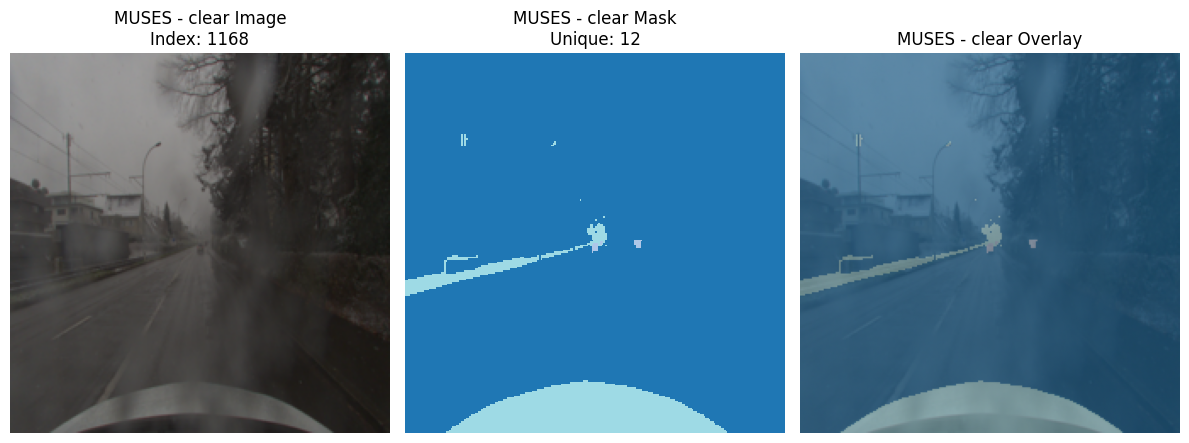

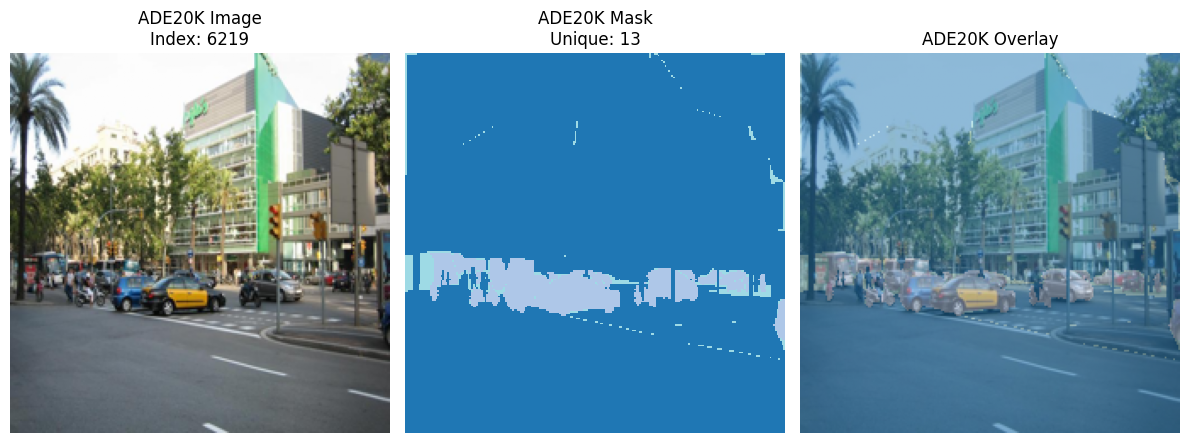

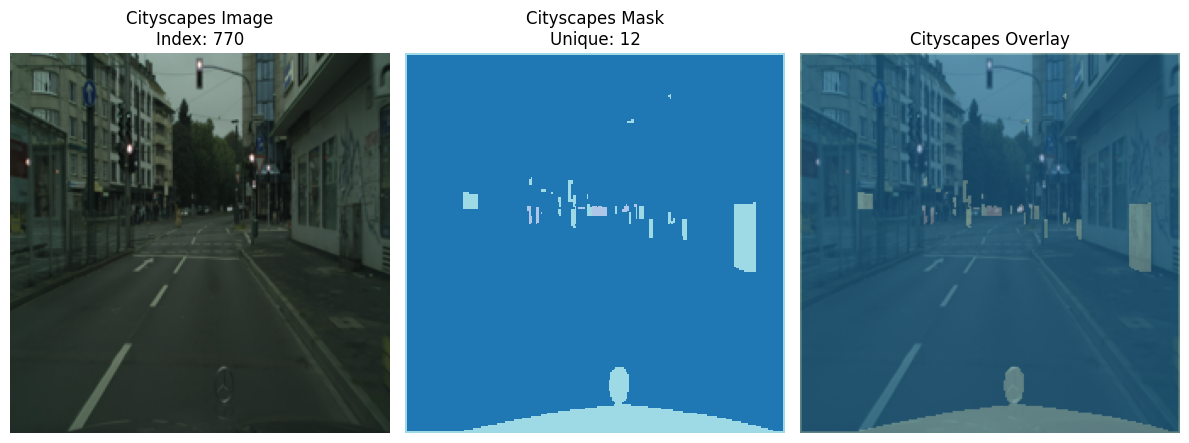

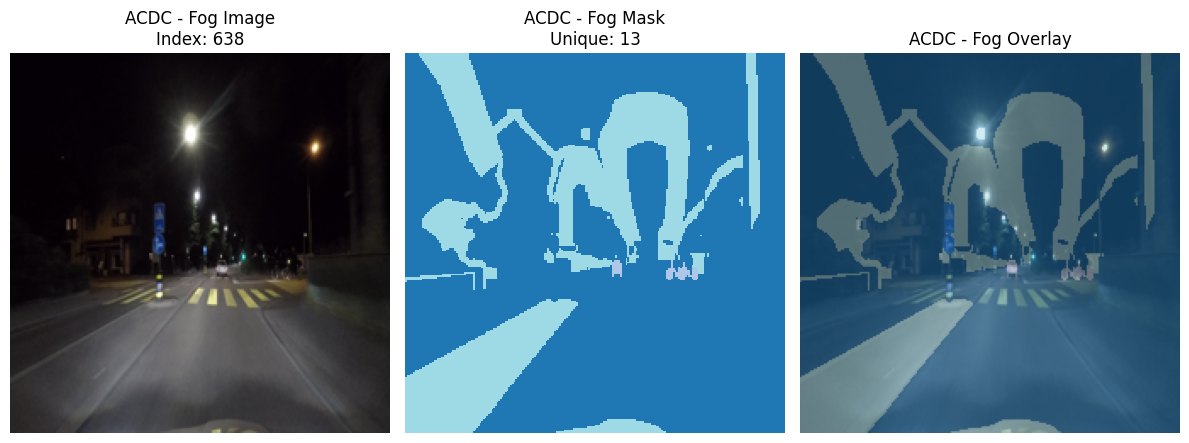

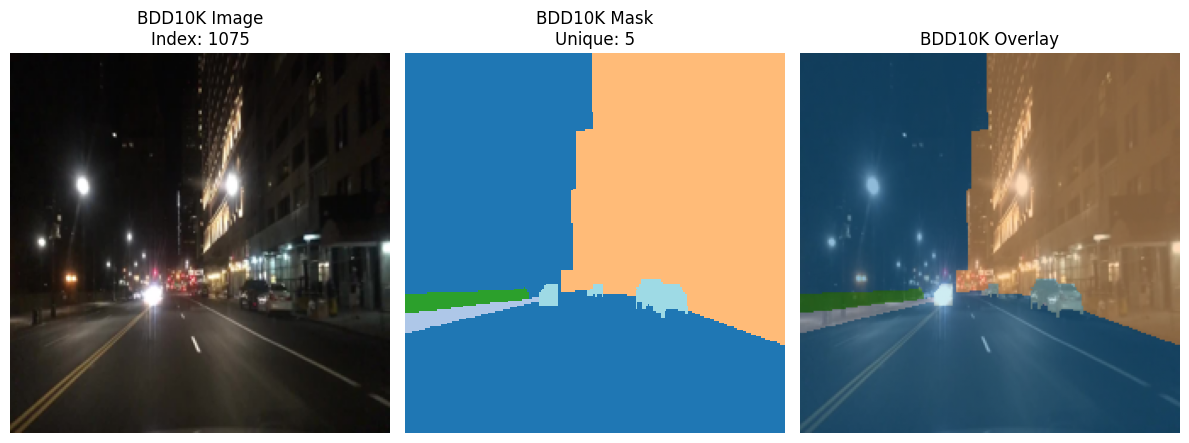

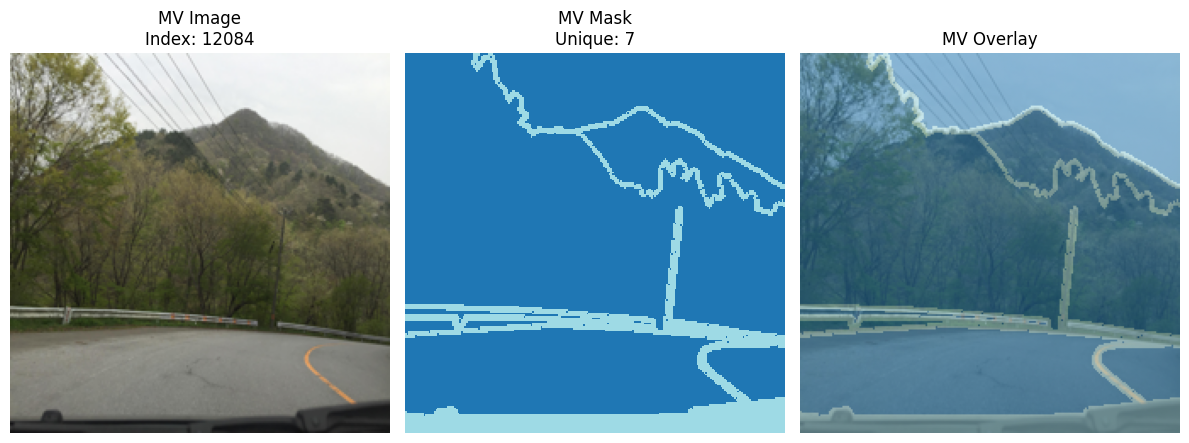

In [17]:
import matplotlib.pyplot as plt
import random

def visualize_sample(dataset, title="Sample"):
    """สุ่มภาพจาก dataset และแสดง overlay กับ mask"""
    idx = random.randint(0, len(dataset)-1)
    # idx = 41
    image, mask = dataset[idx]
    
    # แปลงกลับเป็น HWC สำหรับแสดงผล
    img_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.numpy()
    
    # Normalize ภาพ (เพื่อให้ดูสว่างพอดี)
    img_np = np.clip(img_np, 0, 1)

    # สร้าง overlay
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"{title} Image\nIndex: {idx}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab20", interpolation="nearest")
    plt.title(f"{title} Mask\nUnique: {len(np.unique(mask_np))}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_np)
    plt.imshow(mask_np, cmap="tab20", alpha=0.5)
    plt.title(f"{title} Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# 🧪 ทดสอบแสดงภาพจากแต่ละ Dataset
# ============================================================
# muses_train = MusesDataset("/home/chenyinjia/data/dataset/muses", split="train")
# ade_train = ADE20KDataset("/home/chenyinjia/data/dataset/ADE20k", split="train")
# cs_train = CityscapesDataset("/home/chenyinjia/data/dataset/cityscapes", split="train")
# acdc_train_fog   = ACDCDataset(acdc_dir, weather="fog", split="train")

# print(f"MUSES dataset: {len(muses_train)} samples")
# print(f"ADE20K dataset: {len(ade_train)} samples")

# 🔹 แสดงภาพจาก MUSES
visualize_sample(muses_train, title="MUSES - clear")
# visualize_sample(muses_train_fog, title="MUSES - fog")
# visualize_sample(muses_train_rain, title="MUSES - rain")
# visualize_sample(muses_train_snow, title="MUSES - snow")

# 🔹 แสดงภาพจาก ADE20K
visualize_sample(ade_train, title="ADE20K")

# 🔹 แสดงภาพจาก Cityscapes
visualize_sample(cs_train, title="Cityscapes")

# 🔹 แสดงภาพจาก ACDC (fog)
visualize_sample(acdc_train, title="ACDC - Fog")
# visualize_sample(acdc_train_night, title="ACDC - Night")
# visualize_sample(acdc_train_rain, title="ACDC - Rain")
# visualize_sample(acdc_train_snow, title="ACDC - Snow")

visualize_sample(bdd_train, title="BDD10K")

visualize_sample(mv_train, title="MV")

## Model Definition

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CLIPSegBaseline(nn.Module):
    def __init__(self, clip_model, num_classes=NUM_CLASSES):
        super().__init__()
        self.clip = clip_model.vision_model  # HF: CLIPVisionModel
        self.num_classes = num_classes
        
        # Freeze CLIP encoder
        for param in self.clip.parameters():
            param.requires_grad = False
        
        self.feature_dim = 1024  # usually 768
        
        # Decoder head
        self.decoder = nn.Sequential(
            nn.Conv2d(self.feature_dim, 512, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(p=0.1),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(p=0.05),
            nn.Conv2d(256, num_classes, 1)
        )
    
    def forward(self, x):
        B, _, H, W = x.shape
        seq_len = (H // self.clip.config.patch_size) * (W // self.clip.config.patch_size)  # 14*14=196

        with torch.no_grad():
            # Patch embedding
            x_vit = self.clip.embeddings.patch_embedding(x)  # [B, 768, 14, 14]
            x_vit = x_vit.flatten(2).transpose(1, 2)        # [B, 196, 768]

            # CLS token
            if hasattr(self.clip.embeddings, "cls_token"):
                cls_token = self.clip.embeddings.cls_token.expand(B, -1, -1)
            else:
                cls_token = torch.zeros(B, 1, self.feature_dim, device=x.device)
            x_vit = torch.cat([cls_token, x_vit], dim=1)  # [B, 197, 768]

            # Positional embeddings: index
            pos_ids = torch.arange(x_vit.shape[1], device=x.device)
            pos_embeds = self.clip.embeddings.position_embedding(pos_ids)  # [197, 768]
            x_vit = x_vit + pos_embeds.unsqueeze(0)  # broadcast to [B, 197, 768]

            # LayerNorm
            x_vit = self.clip.pre_layrnorm(x_vit)    
            # x_vit = self.clip.embeddings.ln_pre(x_vit)

            # Transformer
            x_vit = self.clip.encoder(x_vit)[0]
            features = x_vit[:, 1:, :].float()  # skip CLS token

        patch_size = self.clip.config.patch_size
        # Reshape spatial map 14x14
        features = features.reshape(B, H // patch_size, W // patch_size, self.feature_dim)
        features = features.permute(0, 3, 1, 2)  # [B, 768, 14, 14]
        
        # Decode
        seg_logits = self.decoder(features)  # [B, num_classes, 14, 14]
        
        # Upsample
        seg_logits = F.interpolate(seg_logits, size=(H, W), 
                                   mode='bilinear', align_corners=False)
        return seg_logits


In [19]:
import torch

# Create a tensor with default float32
x = torch.tensor([1.0, 2.0, 3.0])
print(f"Original tensor dtype: {x.dtype}")

# Convert to half-precision
y = x.half()
print(f"Half-precision tensor dtype: {y.dtype}")

# Convert to half-precision
z = y.half()
print(f"Half-precision tensor dtype: {z.dtype}")

Original tensor dtype: torch.float32
Half-precision tensor dtype: torch.float16
Half-precision tensor dtype: torch.float16


## Initialize Model

In [20]:
print(torch.__version__)

2.4.0


In [21]:
import clip
# pip3 install clip-by-openai
torch_version = tuple(map(int, torch.__version__.split("+")[0].split(".")))
if torch_version < (2, 6, 0):
    clip_model = CLIPModel.from_pretrained(clip32_dir, use_safetensors=True)
else:
    clip_model = CLIPModel.from_pretrained(clip32_dir)

# clip_model, preprocess = clip.load("ViT-B/16", device=DEVICE)

model = CLIPSegBaseline(clip_model, num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)



print("✅ Model initialized and ready for training.")
# เช็คจำนวน parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")

✅ Model initialized and ready for training.
📊 Total parameters: 309,083,924
📊 Trainable parameters: 5,904,148


In [22]:
# # ====================================================
# # ✅ Final Check ก่อนเทรน
# # ====================================================
# print("=" * 60)
# print("🔍 FINAL PRE-TRAINING CHECK")
# print("=" * 60)

# # 1. เช็ค Device
# print(f"1️⃣ Device: {DEVICE}")
# print(f"   GPU Available: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
#     print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# # 2. เช็ค Model
# print(f"\n2️⃣ Model on device: {next(model.parameters()).device}")
# print(f"   Trainable params: {trainable_params:,}")

# # 3. เช็ค DataLoader
# print(f"\n3️⃣ DataLoader:")
# print(f"   Train batches: {len(train_loader)}")
# print(f"   Val batches: {len(val_loader)}")
# print(f"   Batch size: {BATCH_SIZE}")

# # 4. ทดสอบ 1 batch
# print(f"\n4️⃣ Test forward pass...")
# model.eval()
# test_img, test_mask = next(iter(train_loader))
# test_img = test_img.to(DEVICE)
# test_mask = test_mask.to(DEVICE)

# with torch.no_grad():
#     test_out = model(test_img)
#     test_loss = criterion(test_out, test_mask)

# print(f"   Input shape: {test_img.shape}")
# print(f"   Output shape: {test_out.shape}")
# print(f"   Mask shape: {test_mask.shape}")
# print(f"   Test loss: {test_loss.item():.4f}")
# print(f"   ✅ Forward pass successful!")

# # 5. เช็คโฟลเดอร์
# print(f"\n5️⃣ Checkpoint folder: {'checkpoints' if os.path.exists('checkpoints4') else 'NOT FOUND'}")

# print("\n" + "=" * 60)
# print("✅ ALL CHECKS PASSED! Ready to train!")
# print("=" * 60)
# print(f"\n🚀 Training will run for {EPOCHS} epochs")



✅ Batch loaded successfully!
Image batch shape: torch.Size([32, 3, 224, 224])
Mask batch shape: torch.Size([32, 224, 224])
Unique class IDs: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  13,  14,
         15,  16,  17, 255])


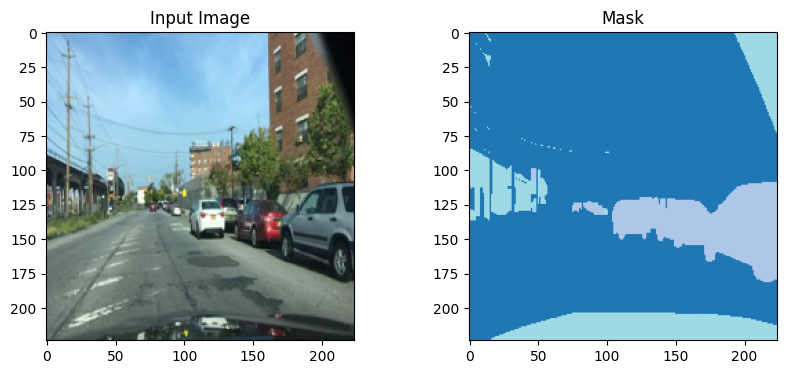

In [23]:
# ============================================================
# STEP 3 — ทดสอบ DataLoader
# ============================================================
from matplotlib import pyplot as plt

# ดึง batch แรกจาก train_loader
images, masks = next(iter(train_loader))

print("✅ Batch loaded successfully!")
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

# ดู unique class IDs ของ mask
unique_classes = torch.unique(masks)
print("Unique class IDs:", unique_classes)

# แสดงภาพและ mask ตัวอย่าง
idx = 0  # index ของภาพใน batch (0 หรือ 1 ก็ได้)
image = images[idx].permute(1, 2, 0).cpu().numpy()
mask = masks[idx].cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab20")
plt.title("Mask")

plt.show()


## Training Loop

Start Training


🔹 Epoch [1/60] | Train Loss: 0.4821 | Val Loss: 0.3092


💾 Saved new best model (Loss: 0.3092)


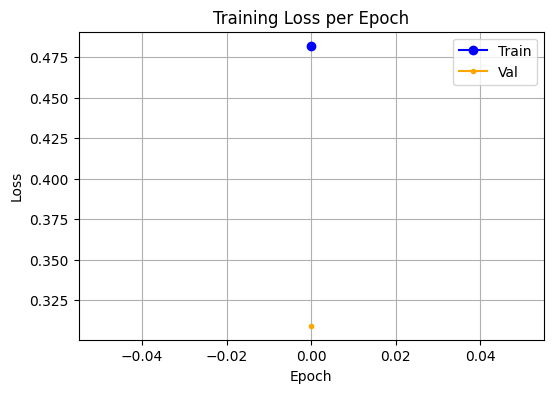

⏰ ETA saved: Estimated completion at 2026-03-07 06:04:22


🔹 Epoch [2/60] | Train Loss: 0.3637 | Val Loss: 0.2947


💾 Saved new best model (Loss: 0.2947)


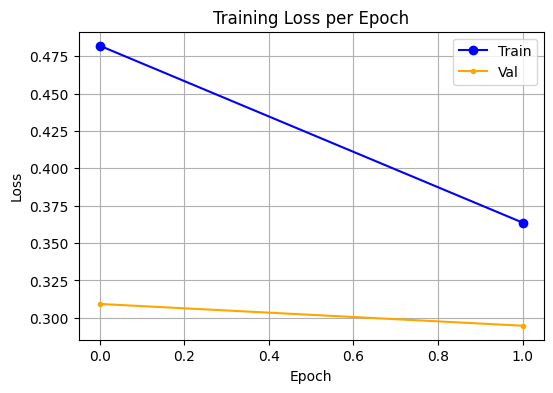

🔹 Epoch [3/60] | Train Loss: 0.3441 | Val Loss: 0.2800


💾 Saved new best model (Loss: 0.2800)


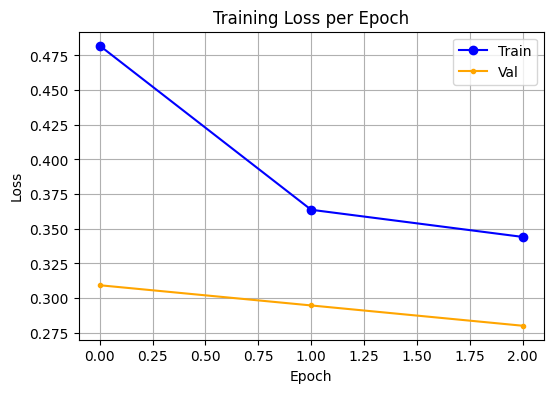

🔹 Epoch [4/60] | Train Loss: 0.3252 | Val Loss: 0.2724


💾 Saved new best model (Loss: 0.2724)


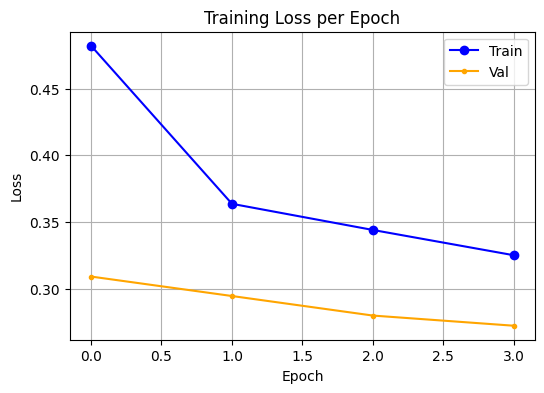

🔹 Epoch [5/60] | Train Loss: 0.3089 | Val Loss: 0.2647


💾 Saved new best model (Loss: 0.2647)


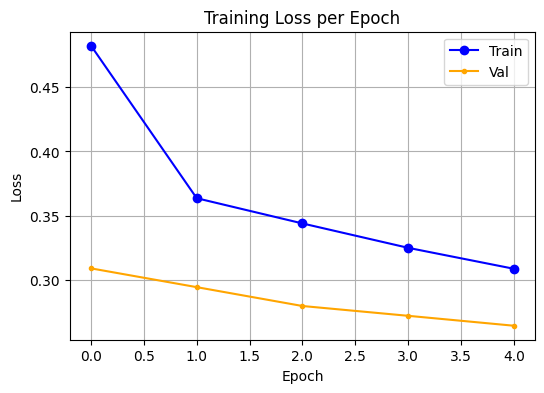

🔹 Epoch [6/60] | Train Loss: 0.2955 | Val Loss: 0.2677


🔹 Epoch [7/60] | Train Loss: 0.2860 | Val Loss: 0.2567


💾 Saved new best model (Loss: 0.2567)


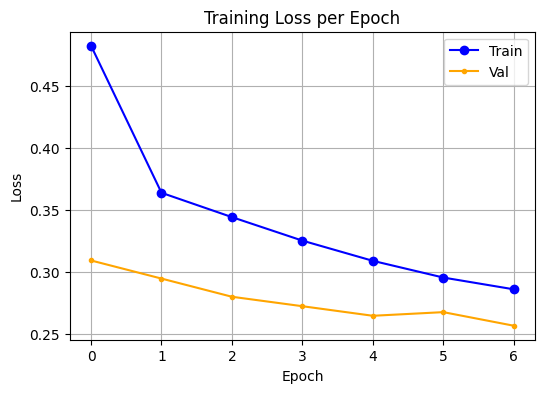

🔹 Epoch [8/60] | Train Loss: 0.2720 | Val Loss: 0.2605


🔹 Epoch [9/60] | Train Loss: 0.2626 | Val Loss: 0.2522


💾 Saved new best model (Loss: 0.2522)


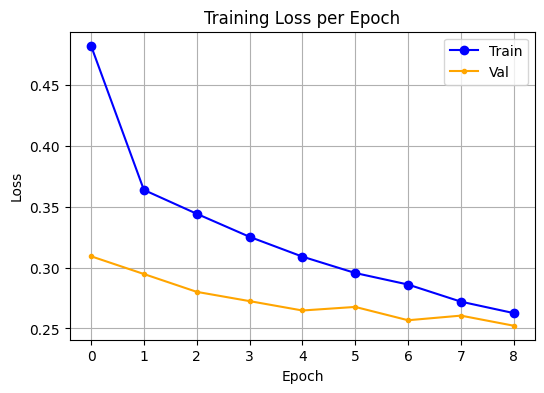

🔹 Epoch [10/60] | Train Loss: 0.2493 | Val Loss: 0.2509


💾 Saved new best model (Loss: 0.2509)


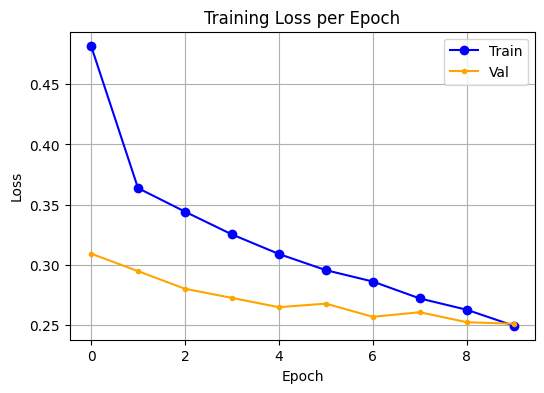

🔹 Epoch [11/60] | Train Loss: 0.2370 | Val Loss: 0.2594


🔹 Epoch [12/60] | Train Loss: 0.2289 | Val Loss: 0.2563


🔹 Epoch [13/60] | Train Loss: 0.2215 | Val Loss: 0.2552


🔹 Epoch [14/60] | Train Loss: 0.2109 | Val Loss: 0.2562


🔹 Epoch [15/60] | Train Loss: 0.2027 | Val Loss: 0.2590
🛑 Early stopping — val loss stagnated.


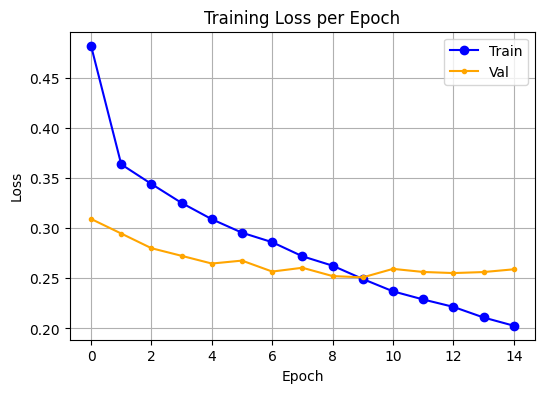

✅ Training completed! Check 'training_eta.txt' for details.


In [24]:
# ============================================================
# Training Loop (Stable + Ignore Index 255 + tqdm)
# ============================================================
from tqdm.notebook import tqdm
import torch
import matplotlib.pyplot as plt

import time
import datetime

# สร้างโฟลเดอร์เซฟโมเดล
os.makedirs("checkpoints4", exist_ok=True)

train_losses, val_losses = [], []
best_loss, patience, bad_epochs = float('inf'), 5, 0

print("Start Training")
#  ตั้ง model ให้อยู่ในโหมด train
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    epoch_start_time = time.time() # Start time for epoch


    for i, (images, masks) in enumerate(train_loader):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        #  ตรวจขนาด mask
        if masks.ndim == 4:
            masks = masks.squeeze(1)

        #  จัดการ ignore index (255) และจำกัดค่าในช่วง [0, NUM_CLASSES-1]
        # masks = torch.where(masks == 255, 0, masks)             # แปลง pixel ไม่มี label เป็น background
        # masks = torch.clamp(masks, 0, NUM_CLASSES - 1).long()

        #  Forward + Backward
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE, dtype=torch.float32):
            outputs = model(images)
            loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ป้องกัน gradient explode
        
        total_loss += loss.item()

    #  Loss ต่อ epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ============================================================
    # 🔍 VALIDATION (half precision + no grad)
    # ============================================================
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_img, val_mask in val_loader:
            val_img = val_img.to(DEVICE, non_blocking=True)
            val_mask = val_mask.to(DEVICE, non_blocking=True).long()

            val_out = model(val_img)
            val_loss += criterion(val_out, val_mask).item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"🔹 Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Update learning rate
    scheduler.step()

    #  Save best model
    if avg_val_loss < best_loss:            # ลองเบสจาก Validation loss
        best_loss, bad_epochs = avg_val_loss, 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_loss,
            'val_loss': avg_val_loss,
        }, f'checkpoints4/{savemodel}.pth')

        # torch.save(model.state_dict(), "clip_seg_best.pt")
        print(f"💾 Saved new best model (Loss: {best_loss:.4f})")
        plt.figure(figsize=(6,4))
        plt.plot(train_losses, label ="Train", marker='o', color='blue')
        plt.plot(val_losses, label ="Val", marker='.', color='orange')
        plt.legend()
        plt.title("Training Loss per Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.savefig(os.path.join('checkpoints4/', f'{savemodel}.png'), dpi=150)
        plt.show()
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("🛑 Early stopping — val loss stagnated.")
            break
    
    torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_loss,
            'val_loss': avg_val_loss,
        }, f'checkpoints4/model{epoch+1}.pth')

    # คำนวณเวลา epoch
    if epoch == 0:
        epoch_time = time.time() - epoch_start_time
        total_estimated_time = epoch_time * EPOCHS
        
        # คำนวณเวลาที่คาดว่าจะเสร็จ
        completion_time = datetime.datetime.now() + datetime.timedelta(seconds=total_estimated_time)
        
        # บันทึก ETA ลงไฟล์ txt
        with open("training_eta.txt", "w") as f:
            f.write(f"Training ETA Estimation\n")
            f.write(f"{'='*40}\n")
            f.write(f"Start Time: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Epoch 1 Time: {epoch_time:.2f} seconds\n")
            f.write(f"Total Epochs: {EPOCHS}\n")
            f.write(f"Estimated Total Time: {total_estimated_time:.2f} seconds ({total_estimated_time/3600:.2f} hours)\n")
            f.write(f"Estimated Completion: {completion_time.strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"First Validate Loss: {avg_val_loss:.4f}\n")
            f.write(f"First Train Loss: {avg_loss:.4f}\n")
            f.write(f"{'='*40}\n")
        
        print(f"⏰ ETA saved: Estimated completion at {completion_time.strftime('%Y-%m-%d %H:%M:%S')}")

    
# ============================================================
# 💾 Save Last Model
# ============================================================
# torch.save(model.state_dict(), "clip_seg_baseline_muses_ade_last_bz8_ep30.pt")
# print("💾 Model saved: clip_seg_baseline_muses_ade_last_bz8_ep30.pt")
# ====== SAVE CHECKPOINT EVERY EPOCH ======
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': avg_loss,
    'val_loss': avg_val_loss,
}, f'checkpoints4/epoch_{epoch+1}.pth')


# ============================================================
# 📈 Plot Training Loss
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(train_losses, label ="Train", marker='o', color='blue')
plt.plot(val_losses, label ="Val", marker='.', color='orange')
plt.legend()
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join('checkpoints4/', f'{savemodel}.png'), dpi=150)
plt.show()


# Model TL
# ============================================================
# 📝 Update ETA File with Actual Completion Time
# ============================================================
with open("training_eta.txt", "a") as f:
    f.write(f"\nActual Completion: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Final Best Loss: {best_loss:.4f}\n")

print("✅ Training completed! Check 'training_eta.txt' for details.")


In [25]:
print(model)

CLIPSegBaseline(
  (clip): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(257, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
  